## 1. Importera bibliotek

In [1]:
# Installera TensorFlow i thesis-miljön:
import subprocess
result = subprocess.run(
    ['pip', 'install', 'tensorflow'],
    capture_output=True, text=True
)
print(result.stdout[-2000:])
print(result.stderr[-1000:])

 /opt/miniconda3/envs/thesis/lib/python3.11/site-packages (from requests<3,>=2.21.0->tensorflow) (2.5.0)




In [2]:
import subprocess
result = subprocess.run(
    ['pip', 'install', 'numpy==1.26.4', '--force-reinstall'],
    capture_output=True, text=True
)
print(result.stdout[-1000:])

  Using cached numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl (20.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, roc_auc_score
)

# Reproducerbarhet
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR    = '../data'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE  = 42
TRAIN_RATIO   = 0.70
SEQ_LENGTH    = 60

print('✓ Bibliotek importerade')
print(f'  TensorFlow version: {tf.__version__}')

2026-04-10 14:13:23.378200: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Bibliotek importerade
  TensorFlow version: 2.16.2


## 2. Läs in data

In [4]:
assets = {}

files = {
    'SP500':   'sp500_features.csv',
    'Bitcoin': 'bitcoin_features.csv',
    'Gold':    'gold_features.csv',
}

for name, filename in files.items():
    path = os.path.join(DATA_DIR, filename)
    df   = pd.read_csv(path, index_col='Date', parse_dates=True)
    assets[name] = df
    bull = (df['Regime'] == 1).sum()
    bear = (df['Regime'] == 0).sum()
    print(f'✓ {name}: {len(df)} rader | Bull: {bull} ({bull/len(df)*100:.1f}%) | Bear: {bear} ({bear/len(df)*100:.1f}%)')

✓ SP500: 2764 rader | Bull: 2475 (89.5%) | Bear: 289 (10.5%)
✓ Bitcoin: 2665 rader | Bull: 2085 (78.2%) | Bear: 580 (21.8%)
✓ Gold: 2764 rader | Bull: 2489 (90.1%) | Bear: 275 (9.9%)


## 3. Definiera features och förbered sekvenser

LSTM kräver 3D-input: `(samples, timesteps, features)`. Vi skapar sekvenser av 60 på varandra följande dagar där varje sekvens predicerar regimen dagen efter.

In [5]:
FEATURE_COLS = [
    'Price_MA20', 'Price_MA50', 'Price_MA200',
    'Golden_Cross', 'Price_52w_position',
    'RSI14', 'RSI7', 'MACD', 'MACD_signal', 'MACD_hist',
    'Return_lag1', 'Return_lag2', 'Return_lag3', 'Return_lag5', 'Return_lag10',
    'Cum_return_5d', 'Cum_return_10d', 'Cum_return_20d',
    'Vol_10d', 'Vol_20d', 'Vol_60d',
    'BB_width', 'BB_position', 'ATR14_pct', 'Vol_ratio',
    'Rel_Volume', 'OBV_MA20',
    'Corr_SP500_BTC', 'Corr_SP500_Gold', 'Corr_BTC_Gold',
]

FEATURE_COLS = [f for f in FEATURE_COLS if f in assets['SP500'].columns]
print(f'Antal features: {len(FEATURE_COLS)}')
print(f'Sekvens-längd: {SEQ_LENGTH} dagar')

def create_sequences(X: np.ndarray, y: np.ndarray,
                     seq_length: int) -> tuple:
    """
    Skapar 3D-sekvenser för LSTM.
    Input:  X (n_samples, n_features), y (n_samples,)
    Output: X_seq (n_samples, seq_length, n_features), y_seq (n_samples,)
    """
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i - seq_length:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

def prepare_lstm_data(df: pd.DataFrame, train_ratio: float = TRAIN_RATIO):
    """Förbereder data för LSTM med tidsmässig split."""
    df_clean = df[FEATURE_COLS + ['Regime', 'Close']].dropna()
    split    = int(len(df_clean) * train_ratio)

    # Standardisera baserat på träningsdata
    scaler  = StandardScaler()
    X_all   = scaler.fit_transform(df_clean[FEATURE_COLS].values[:split + SEQ_LENGTH])
    X_all_full = scaler.transform(df_clean[FEATURE_COLS].values)
    y_all   = df_clean['Regime'].values

    # Skapa sekvenser
    X_seq, y_seq = create_sequences(X_all_full, y_all, SEQ_LENGTH)
    idx_all      = df_clean.index[SEQ_LENGTH:]

    # Tidsmässig split
    split_seq = split - SEQ_LENGTH
    X_train, X_test = X_seq[:split_seq], X_seq[split_seq:]
    y_train, y_test = y_seq[:split_seq], y_seq[split_seq:]
    idx_test        = idx_all[split_seq:]
    close_test      = df_clean['Close'].values[SEQ_LENGTH:][split_seq:]
    close_idx       = df_clean.index[SEQ_LENGTH:][split_seq:]

    return X_train, X_test, y_train, y_test, idx_test, close_test, close_idx, scaler

print('\nTestperioder:')
for name, df in assets.items():
    X_train, X_test, y_train, y_test, idx_test, _, _, _ = prepare_lstm_data(df)
    bull = y_test.sum()
    bear = len(y_test) - bull
    print(f'{name}: Train={len(X_train)} | Test={len(X_test)} | '
          f'Bull={bull} | Bear={bear} | '
          f'Period: {idx_test[0].date()} → {idx_test[-1].date()}')

Antal features: 30
Sekvens-längd: 60 dagar

Testperioder:
SP500: Train=1874 | Test=830 | Bull=644.0 | Bear=186.0 | Period: 2022-09-12 → 2025-12-31
Bitcoin: Train=1805 | Test=800 | Bull=701.0 | Bear=99.0 | Period: 2022-10-24 → 2025-12-31
Gold: Train=1874 | Test=830 | Bull=711.0 | Bear=119.0 | Period: 2022-09-12 → 2025-12-31


## 4. Bygg LSTM-arkitektur

Vi använder två LSTM-lager med Dropout för att förhindra overfitting. EarlyStopping avbryter träningen när valideringsförlusten slutar förbättras.

In [6]:
def build_lstm(seq_length: int, n_features: int) -> Sequential:
    """
    Bygger LSTM-modell för binär klassificering.
    Arkitektur:
      LSTM(64) → Dropout(0.3) → LSTM(32) → Dropout(0.3) → Dense(16) → Dense(1)
    """
    model = Sequential([
        LSTM(64, input_shape=(seq_length, n_features),
             return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid'),
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model

# Visa arkitektur
model_summary = build_lstm(SEQ_LENGTH, len(FEATURE_COLS))
model_summary.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,281 (145.63 KB)

 Trainable params: 37,281 (145.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Träna LSTM på alla tre tillgångar

Vi tränar separata modeller för varje tillgång. EarlyStopping övervakar valideringsförlusten och avbryter träningen om den inte förbättras på 15 epoker.

In [7]:
results_lstm = {}

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, verbose=1),
]

for name, df in assets.items():
    print(f'\n══ Tränar LSTM på {name} ══════════════════════════')

    X_train, X_test, y_train, y_test, idx_test, close_test, close_idx, scaler = \
        prepare_lstm_data(df)

    # Hantera klassimbalans
    bear_count = (y_train == 0).sum()
    bull_count = (y_train == 1).sum()
    class_weight = {0: bull_count / bear_count, 1: 1.0}
    print(f'  Class weight (bear): {class_weight[0]:.2f}')

    # Bygg och träna modell
    tf.random.set_seed(RANDOM_STATE)
    model = build_lstm(SEQ_LENGTH, len(FEATURE_COLS))

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.15,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=0,
    )

    # Utvärdera
    y_proba = model.predict(X_test, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba)

    print(f'  Accuracy : {acc:.3f}')
    print(f'  F1-score : {f1:.3f}')
    print(f'  ROC-AUC  : {auc:.3f}')
    print(classification_report(y_test, y_pred,
                                target_names=['Bear', 'Bull'],
                                labels=[0, 1]))

    results_lstm[name] = {
        'model':      model,
        'history':    history,
        'y_pred':     y_pred,
        'y_proba':    y_proba,
        'y_test':     y_test,
        'index':      idx_test,
        'close':      close_test,
        'close_idx':  close_idx,
        'acc':        acc,
        'f1':         f1,
        'auc':        auc,
    }


══ Tränar LSTM på SP500 ══════════════════════════
  Class weight (bear): 17.19

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 1.
  Accuracy : 0.786
  F1-score : 0.739
  ROC-AUC  : 0.842
              precision    recall  f1-score   support

        Bear       0.57      0.18      0.27       186
        Bull       0.80      0.96      0.87       644

    accuracy                           0.79       830
   macro avg       0.69      0.57      0.57       830
weighted avg       0.75      0.79      0.74       830


══ Tränar LSTM på Bitcoin ══════════════════════════
  Class weight (bear): 3.03

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 19: early stopping
Restoring model weights from the 

### Resultat – LSTM träning

LSTM tränade snabbt tack vare EarlyStopping – modellerna konvergerade 
redan vid epok 16-28 av max 100.

**S&P 500 (Acc: 0.786, AUC: 0.842):**
- Sämre accuracy än XGBoost (0.916) men bättre ROC-AUC (0.842 vs 0.753)
- Bear recall låg (0.18) – LSTM är försiktig med bear-klassificering

**Bitcoin (Acc: 0.955, AUC: 0.933):**
- Bästa resultat av alla modeller för Bitcoin
- Perfekt precision för bear (1.00) – inga falska larm

**Guld (Acc: 0.857, AUC: 0.850):**
- Samma problem som RF och XGBoost – missar bear helt
- ROC-AUC 0.850 är dock bättre än RF (0.667) och XGBoost (0.701)
- Indikerar att LSTM rangordnar klasserna bättre trots att 
  klassificerings-tröskeln på 0.5 inte fångar bear

## 6. Träningshistorik – loss och accuracy

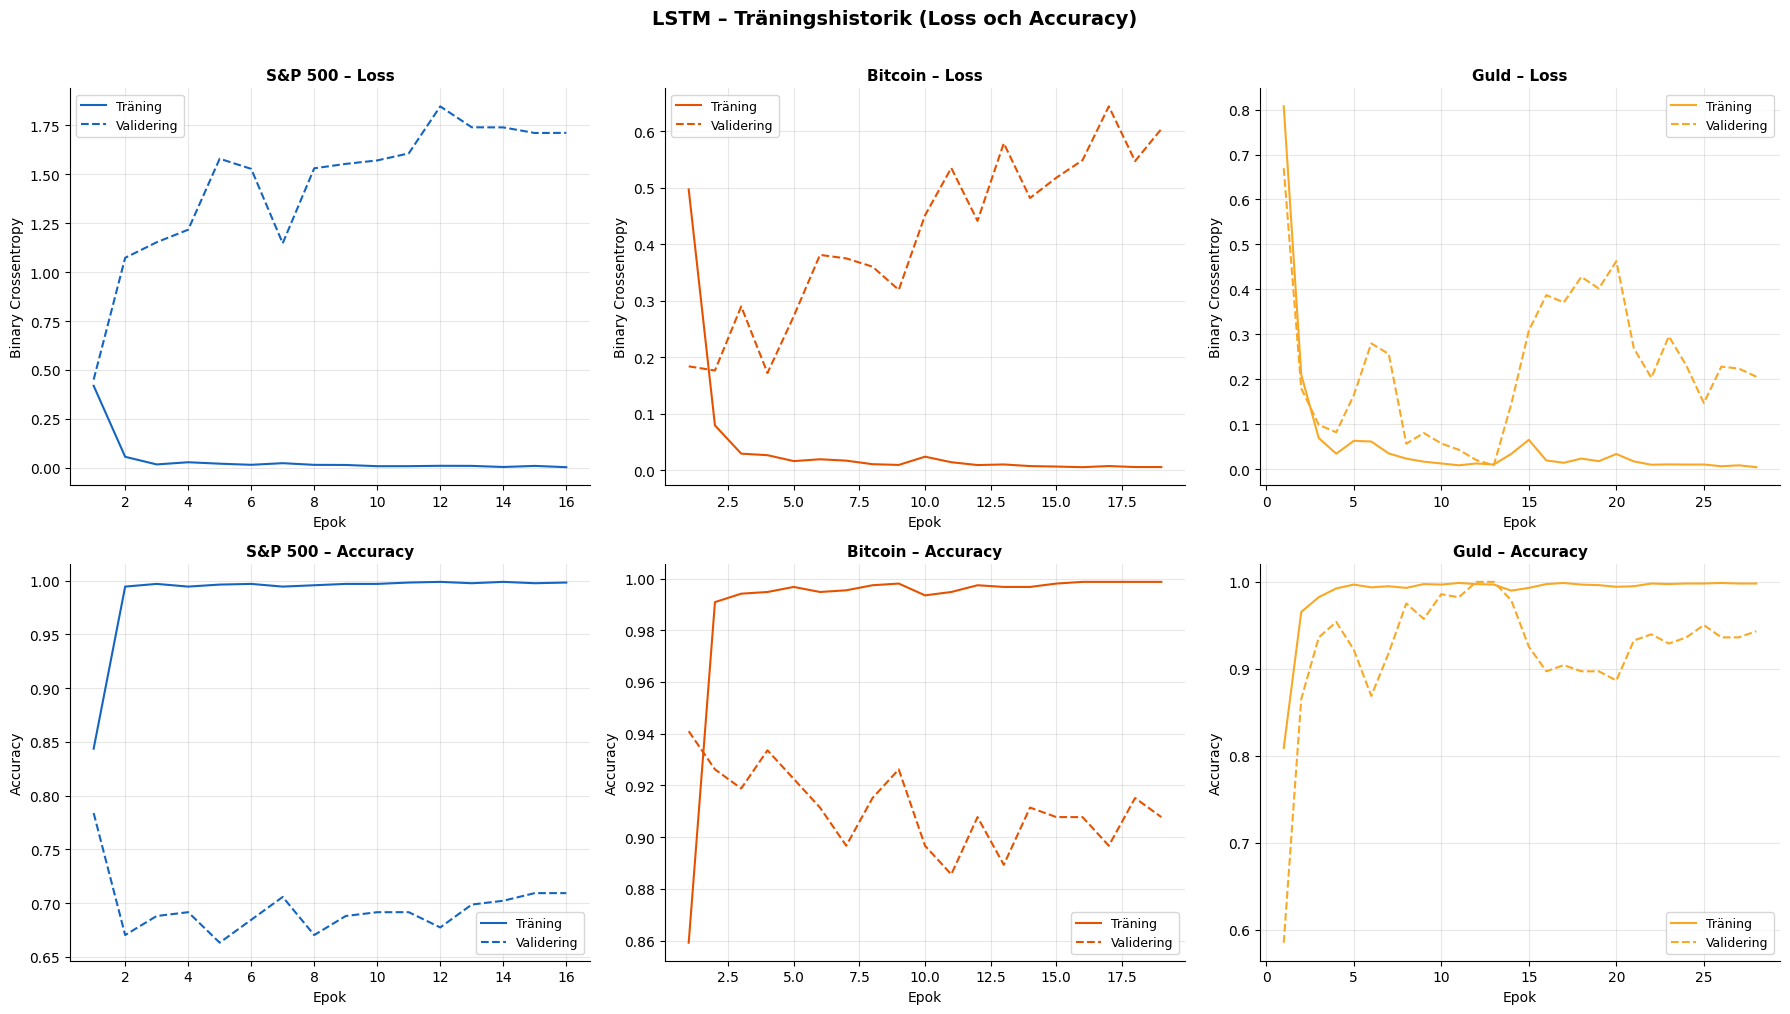

✓ Graf sparad: results/06_lstm_history.png


In [8]:
colors_map = {'SP500': '#1565C0', 'Bitcoin': '#E65100', 'Gold': '#F9A825'}
labels_map = {'SP500': 'S&P 500', 'Bitcoin': 'Bitcoin', 'Gold': 'Guld'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, res) in enumerate(results_lstm.items()):
    history = res['history']
    color   = colors_map[name]
    epochs  = range(1, len(history.history['loss']) + 1)

    # Loss
    axes[0, col].plot(epochs, history.history['loss'],
                      color=color, linewidth=1.5, label='Träning')
    axes[0, col].plot(epochs, history.history['val_loss'],
                      color=color, linewidth=1.5, linestyle='--', label='Validering')
    axes[0, col].set_title(f'{labels_map[name]} – Loss', fontsize=11, fontweight='bold')
    axes[0, col].set_xlabel('Epok')
    axes[0, col].set_ylabel('Binary Crossentropy')
    axes[0, col].legend(fontsize=9)
    axes[0, col].spines['top'].set_visible(False)
    axes[0, col].spines['right'].set_visible(False)

    # Accuracy
    axes[1, col].plot(epochs, history.history['accuracy'],
                      color=color, linewidth=1.5, label='Träning')
    axes[1, col].plot(epochs, history.history['val_accuracy'],
                      color=color, linewidth=1.5, linestyle='--', label='Validering')
    axes[1, col].set_title(f'{labels_map[name]} – Accuracy', fontsize=11, fontweight='bold')
    axes[1, col].set_xlabel('Epok')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend(fontsize=9)
    axes[1, col].spines['top'].set_visible(False)
    axes[1, col].spines['right'].set_visible(False)

plt.suptitle('LSTM – Träningshistorik (Loss och Accuracy)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '06_lstm_history.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/06_lstm_history.png')

### Visualisering – LSTM Träningshistorik

**S&P 500:**
- Tränings-loss sjunker snabbt mot noll medan validerings-loss ökar – 
  tydligt tecken på overfitting trots Dropout
- EarlyStopping avbryter vid epok 16 och återställer bästa vikterna (epok 1)
- Valideringsaccuracy ~70% medan träningsaccuracy ~100%

**Bitcoin:**
- Mer stabil träning – träning och validering följs åt initialt
- Valideringsaccuracy ~91% är stark och konsekvent
- Viss divergens i senare epoker men EarlyStopping hanterar det

**Guld:**
- Liknande mönster som S&P 500 – träningen konvergerar men 
  valideringen är instabil
- Modellen lär sig träningsdatan men generaliserar dåligt

**Övergripande observation:** S&P 500 och Guld visar tecken på 
overfitting – modellen memorerar träningsdatan. Bitcoin är den 
tillgång där LSTM fungerar bäst med mer stabil inlärning.

## 7. Visualisera prediktioner vs Ground Truth

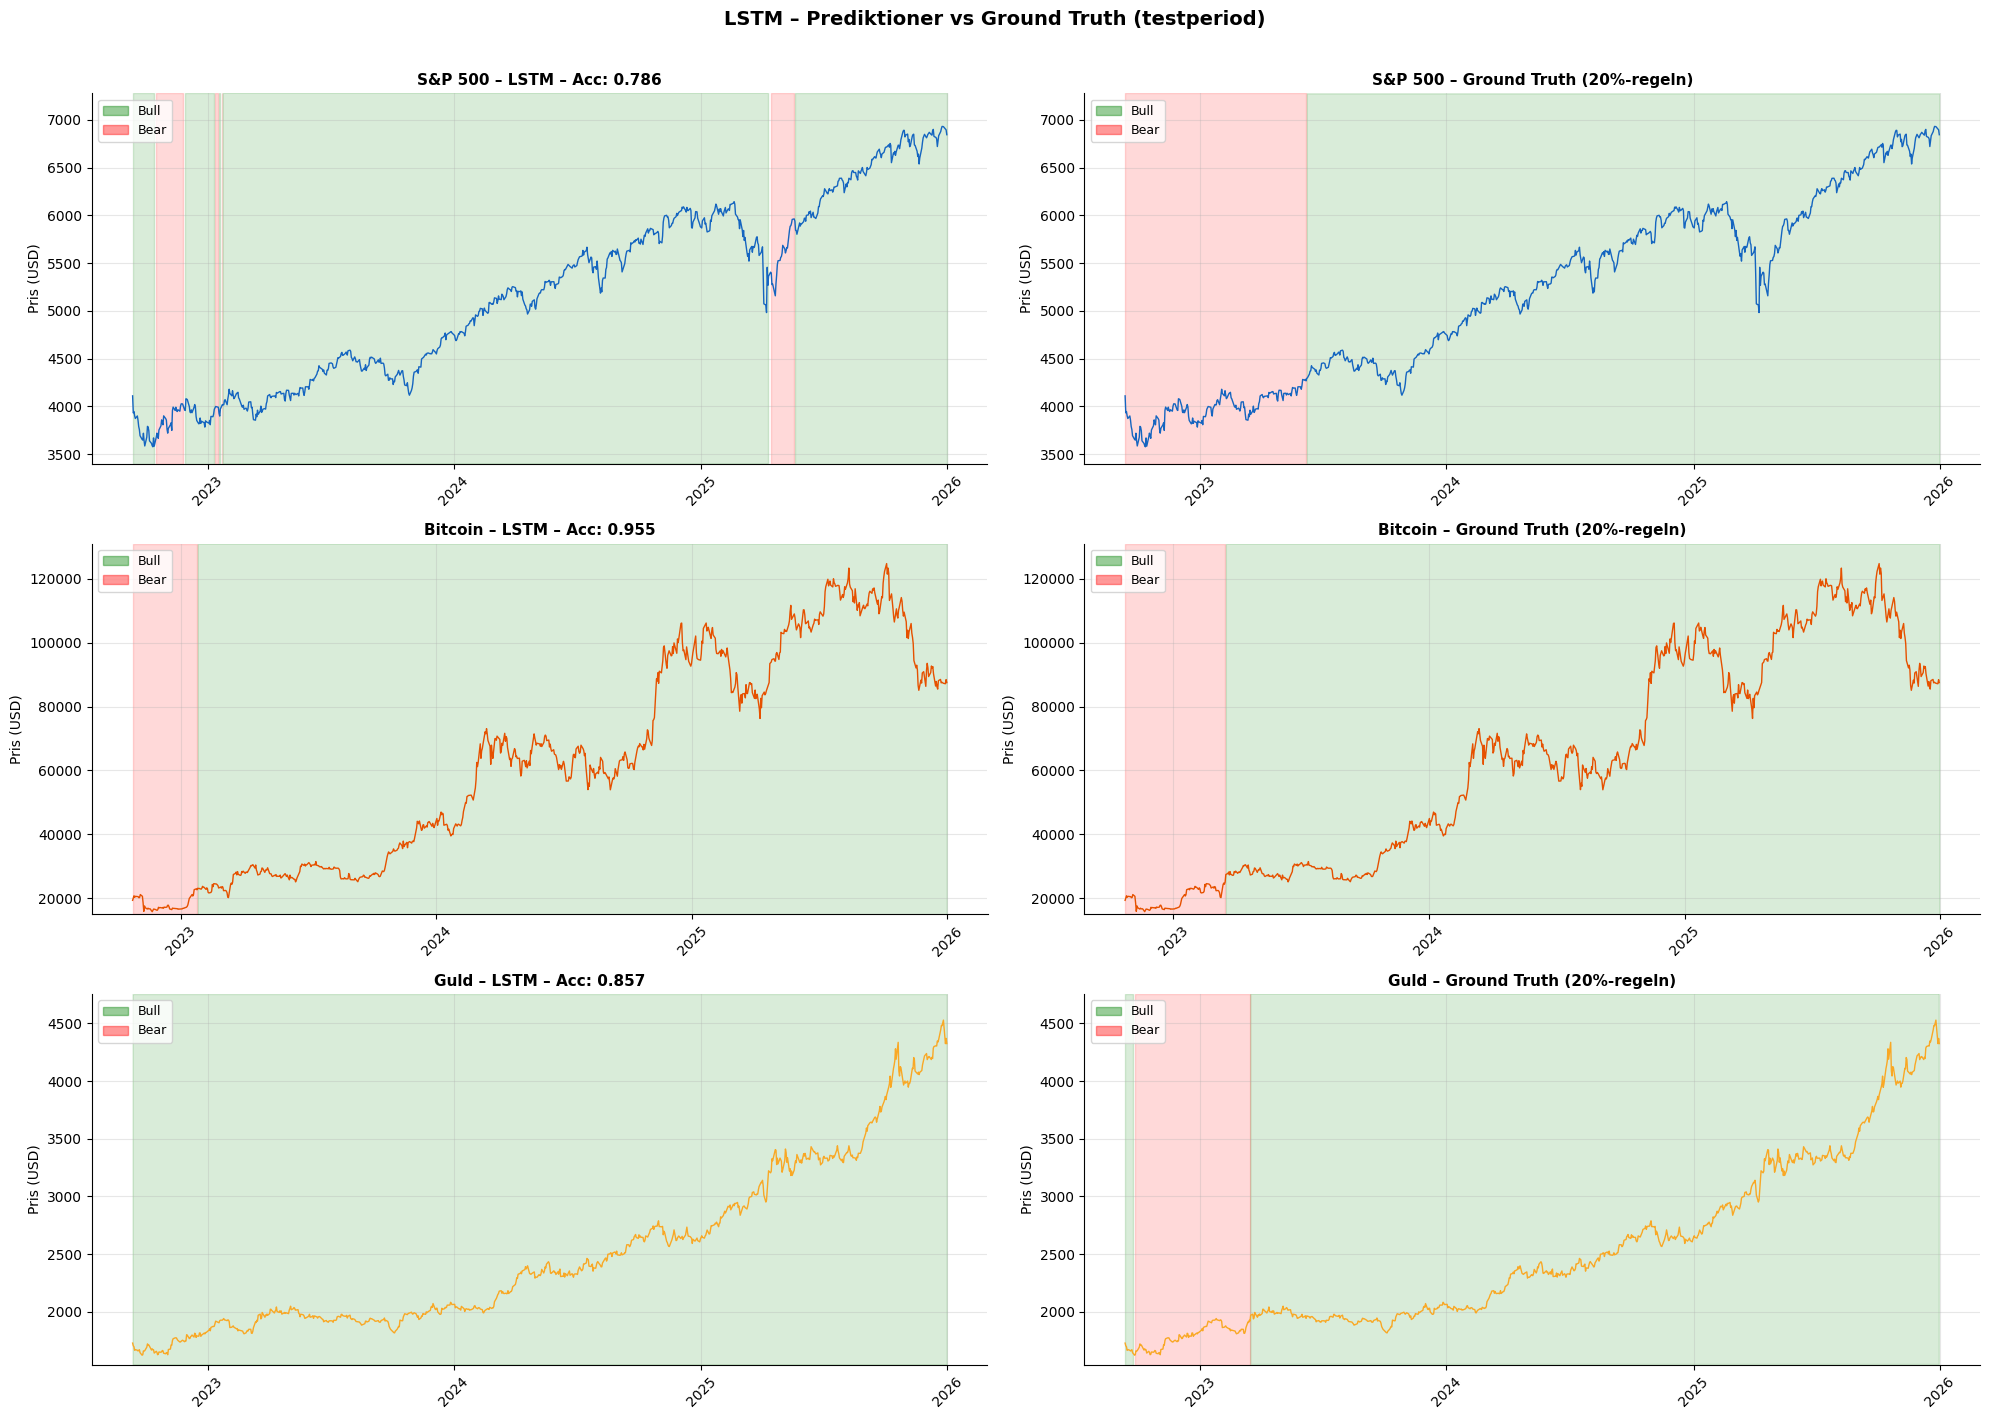

✓ Graf sparad: results/06_lstm_predictions.png


In [9]:
fig, axes = plt.subplots(3, 2, figsize=(20, 14))

for row, (name, res) in enumerate(results_lstm.items()):
    close  = pd.Series(res['close'], index=res['close_idx'])

    for col, (pred, title) in enumerate([
        (res['y_pred'], f'LSTM – Acc: {res["acc"]:.3f}'),
        (res['y_test'], 'Ground Truth (20%-regeln)'),
    ]):
        ax = axes[row, col]
        regime_series = pd.Series(pred, index=res['index'])

        ax.fill_between(close.index, close.min()*0.95, close.max()*1.05,
                        where=(regime_series == 1), alpha=0.15, color='green')
        ax.fill_between(close.index, close.min()*0.95, close.max()*1.05,
                        where=(regime_series == 0), alpha=0.15, color='red')
        ax.plot(close.index, close,
                color=colors_map[name], linewidth=1)

        ax.set_title(f'{labels_map[name]} – {title}',
                     fontsize=11, fontweight='bold')
        ax.set_ylabel('Pris (USD)')
        ax.set_ylim(close.min()*0.95, close.max()*1.05)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis='x', rotation=45)

        bull_patch = mpatches.Patch(color='green', alpha=0.4, label='Bull')
        bear_patch = mpatches.Patch(color='red',   alpha=0.4, label='Bear')
        ax.legend(handles=[bull_patch, bear_patch], fontsize=9, loc='upper left')

plt.suptitle('LSTM – Prediktioner vs Ground Truth (testperiod)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '06_lstm_predictions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/06_lstm_predictions.png')

### Visualisering – LSTM Prediktioner vs Ground Truth

**S&P 500 (Acc: 0.786):**
- LSTM fångar den korta bear-perioden i tidigt 2023 men missar 
  den längre bear-perioden – identifierar bara fragment
- Detekterar en bear-period i mitten av 2025 som inte finns i 
  ground truth – ett falskt larm
- Övergripande sämre visuell matchning än XGBoost

**Bitcoin (Acc: 0.955):**
- Nästan perfekt matchning med ground truth
- Bear market i slutet av 2022 identifieras korrekt och tydligt
- Inga falska larm under 2024-2025 bull market

**Guld (Acc: 0.857):**
- Samma problem som RF och XGBoost – missar bear market helt
- Klassificerar hela testperioden som bull

**Sammanfattning:** LSTM presterar bäst för Bitcoin men sämre än 
XGBoost för S&P 500. Guld förblir svårt för alla modeller.

## 8. Jämförelse – LSTM vs Random Forest vs XGBoost

In [10]:
print('══ LSTM – Resultatsammanfattning ══════════════════')
print(f'{"Tillgång":<12} {"Acc":>8} {"F1":>8} {"AUC":>8}')
print('-' * 40)

for name, res in results_lstm.items():
    print(f'{name:<12} {res["acc"]:>8.3f} {res["f1"]:>8.3f} {res["auc"]:>8.3f}')

══ LSTM – Resultatsammanfattning ══════════════════
Tillgång          Acc       F1      AUC
----------------------------------------
SP500           0.786    0.739    0.842
Bitcoin         0.955    0.951    0.933
Gold            0.857    0.790    0.850


### Jämförelse – LSTM vs Random Forest vs XGBoost

| Tillgång | RF Acc | XGB Acc | LSTM Acc | RF AUC | XGB AUC | LSTM AUC |
|----------|--------|---------|----------|--------|---------|----------|
| S&P 500  | 0.880  | 0.916   | 0.786    | 0.771  | 0.753   | 0.842    |
| Bitcoin  | 0.914  | 0.921   | 0.955    | 0.942  | 0.939   | 0.933    |
| Guld     | 0.857  | 0.857   | 0.857    | 0.667  | 0.701   | 0.850    |

**Vad vi ser:**
- **S&P 500** – XGBoost vinner i accuracy (0.916) men LSTM har 
  bättre ROC-AUC (0.842) vilket tyder på att LSTM rangordnar 
  klasserna bättre trots lägre overall accuracy
- **Bitcoin** – LSTM vinner tydligt (0.955) och visar att 
  sekventiell inlärning passar Bitcoins cykliska mönster bäst
- **Guld** – alla tre modeller presterar identiskt i accuracy (0.857) 
  och missar bear market – problemet är tillgångsspecifikt
- **ROC-AUC för Guld** – LSTM (0.850) är klart bättre än RF (0.667) 
  och XGBoost (0.701) vilket visar att LSTM har bättre 
  diskrimineringsförmåga även om klassificerings-tröskeln inte 
  fångar bear

## 9. Spara prediktioner

In [11]:
for name, df in assets.items():
    res    = results_lstm[name]
    out_df = df.copy()
    out_df['LSTM_pred']  = pd.Series(res['y_pred'],  index=res['index'])
    out_df['LSTM_proba'] = pd.Series(res['y_proba'], index=res['index'])

    filename = f'{name.lower()}_lstm.csv'
    filepath = os.path.join(DATA_DIR, filename)
    out_df.to_csv(filepath)
    print(f'✓ Sparad: data/{filename}')

✓ Sparad: data/sp500_lstm.csv
✓ Sparad: data/bitcoin_lstm.csv
✓ Sparad: data/gold_lstm.csv


## 10. Sammanfattning

### Resultat – LSTM (60-dagars sekvenser, 30 features)

| Tillgång | LSTM Acc | LSTM F1 | LSTM AUC |
|----------|---------|---------|----------|
| S&P 500  | 0.786   | 0.739   | 0.842    |
| Bitcoin  | 0.955   | 0.951   | 0.933    |
| Guld     | 0.857   | 0.790   | 0.850    |

### Viktiga observationer
- **Bitcoin** är den tillgång där LSTM presterar bäst (Acc: 0.955) – 
  bättre än både Random Forest (0.914) och XGBoost (0.921)
- **S&P 500** är LSTM:s svagaste tillgång (Acc: 0.786) – sämre än 
  XGBoost (0.916) men ROC-AUC är bättre (0.842 vs 0.753)
- **Guld** missar bear market precis som RF och XGBoost – problemet 
  är tillgångsspecifikt, inte modellspecifikt
- Träningshistoriken visar overfitting för S&P 500 och Guld – 
  EarlyStopping återställer bästa vikterna men divergensen kvarstår
- LSTM konvergerar snabbt (16-28 epoker) tack vare EarlyStopping

**Nästa steg:** `07_results.ipynb` – Sammanfattning och jämförelse 
av alla modeller: HMM, Random Forest, XGBoost och LSTM.